# ⚛️ Quantum QUBO Band Selection + Full-Dataset Classical ML
### Salinas Hyperspectral — IBM Quantum Hardware (30 qubits, 20 bands)

**Each classifier runs in its own cell — no need to retrain if one fails.**

**Run cells top to bottom. Upload files only once in Cell 2.**

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — Install packages
# ═══════════════════════════════════════════════════════════════════════════
import sys, subprocess

packages = [
    'numpy', 'scipy', 'scikit-learn', 'matplotlib',
    'qiskit>=2.0.0', 'xgboost'
]
print('Installing packages...')
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages installed ✓')

Installing packages...
All packages installed ✓


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — Upload files + Load entire dataset
# Run this cell ONCE. All data stays in memory for all later cells.
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
import scipy.io
import os
from google.colab import files

print('Please upload BOTH files: Salinas.mat and Salinas_gt.mat')
uploaded = files.upload()
uploaded_names = list(uploaded.keys())
print(f'\nFiles received: {uploaded_names}')

salinas_path    = None
salinas_gt_path = None
for name in uploaded_names:
    path = f'/content/{name}'
    if 'gt' in name.lower():
        salinas_gt_path = path
    else:
        salinas_path = path

print(f'  Image file : {salinas_path}')
print(f'  GT file    : {salinas_gt_path}')

if salinas_path is None or salinas_gt_path is None:
    raise FileNotFoundError('Could not find both files. Upload Salinas.mat AND Salinas_gt.mat')

def get_array(mat_dict, preferred_keys):
    for k in preferred_keys:
        if k in mat_dict:
            return mat_dict[k]
    for k, v in mat_dict.items():
        if not k.startswith('_') and isinstance(v, np.ndarray) and v.ndim >= 2:
            return v
    raise KeyError(f'Array not found. Keys: {list(mat_dict.keys())}')

raw_salinas    = scipy.io.loadmat(salinas_path)
raw_salinas_gt = scipy.io.loadmat(salinas_gt_path)

img = get_array(raw_salinas,    ['salinas', 'Salinas'])
gt  = get_array(raw_salinas_gt, ['salinas_gt', 'Salinas_gt'])

h_img, w_img, N_ALL_BANDS = img.shape
img_full = img.copy()
gt_full  = gt.copy()

X_all      = img.reshape(-1, N_ALL_BANDS).astype(np.float64)
y_all      = gt.reshape(-1)
mask       = y_all > 0
X_labeled  = X_all[mask]
y_labeled  = y_all[mask]
unique_cls = np.unique(y_labeled)

labeled_positions = np.argwhere(gt.reshape(h_img, w_img) > 0)

CLASS_NAMES = {
    1:'Broccoli_green_weeds_1', 2:'Broccoli_green_weeds_2',
    3:'Fallow',                 4:'Fallow_rough_plow',
    5:'Fallow_smooth',          6:'Stubble',
    7:'Celery',                 8:'Grapes_untrained',
    9:'Soil_vinyard_develop',   10:'Corn_senesced_green_weeds',
    11:'Lettuce_romaine_4wk',   12:'Lettuce_romaine_5wk',
    13:'Lettuce_romaine_6wk',   14:'Lettuce_romaine_7wk',
    15:'Vinyard_untrained',     16:'Vinyard_vertical_trellis',
}

print(f'\n✓ Dataset loaded successfully')
print(f'  Image shape    : {h_img} x {w_img} x {N_ALL_BANDS} bands')
print(f'  Labeled pixels : {len(y_labeled):,}')
print(f'  Classes        : {len(unique_cls)}')
print()
for c in unique_cls:
    cnt  = (y_labeled == c).sum()
    name = CLASS_NAMES.get(int(c), f'Class {c}')
    bar  = '█' * int(cnt / 500)
    print(f'  Class {int(c):2d}  {name:35s}: {cnt:6,}  {bar}')

Please upload BOTH files: Salinas.mat and Salinas_gt.mat


Saving Salinas.mat to Salinas.mat
Saving Salinas_gt.mat to Salinas_gt.mat

Files received: ['Salinas.mat', 'Salinas_gt.mat']
  Image file : /content/Salinas.mat
  GT file    : /content/Salinas_gt.mat

✓ Dataset loaded successfully
  Image shape    : 512 x 217 x 224 bands
  Labeled pixels : 54,129
  Classes        : 16

  Class  1  Broccoli_green_weeds_1             :  2,009  ████
  Class  2  Broccoli_green_weeds_2             :  3,726  ███████
  Class  3  Fallow                             :  1,976  ███
  Class  4  Fallow_rough_plow                  :  1,394  ██
  Class  5  Fallow_smooth                      :  2,678  █████
  Class  6  Stubble                            :  3,959  ███████
  Class  7  Celery                             :  3,579  ███████
  Class  8  Grapes_untrained                   : 11,271  ██████████████████████
  Class  9  Soil_vinyard_develop               :  6,203  ████████████
  Class 10  Corn_senesced_green_weeds          :  3,278  ██████
  Class 11  Lettuce_roma

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — Imports & Configuration
# ═══════════════════════════════════════════════════════════════════════════
import time
import warnings
import itertools
import random
import pickle
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, VotingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from scipy.stats import loguniform, randint
from xgboost import XGBClassifier

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler

warnings.filterwarnings('ignore')

# ── QUBO config ───────────────────────────────────────────────────────────
N_BANDS_SELECT    = 20
N_CANDIDATE_BANDS = 30
QUBO_PENALTY      = 5.0
CORR_PENALTY      = 0.5
QAOA_DEPTH        = 1
QAOA_SHOTS        = 4096
N_GAMMA           = 8
N_BETA            = 8
FISHER_SAMPLES    = 1000

# ── ML config ─────────────────────────────────────────────────────────────
TEST_SPLIT     = 0.10
CV_FOLDS       = 5
SPATIAL_WINDOW = 3

# ── Pickle helper — saves results after every classifier ─────────────────
BACKUP_PATH = '/content/results_backup.pkl'

def save_results(results):
    with open(BACKUP_PATH, 'wb') as f:
        pickle.dump(results, f)
    print(f'  ✓ Results saved to {BACKUP_PATH}  [{list(results.keys())}]')

def load_results():
    if os.path.exists(BACKUP_PATH):
        with open(BACKUP_PATH, 'rb') as f:
            r = pickle.load(f)
        print(f'  ✓ Restored results: {list(r.keys())}')
        return r
    return {}

# Initialise results dict
results = {}

print('=' * 65)
print('QUANTUM QUBO + SPATIAL-SPECTRAL CLASSIFICATION (HIGH ACCURACY)')
print('=' * 65)
print(f'  QUBO     : select {N_BANDS_SELECT} bands from top-{N_CANDIDATE_BANDS} Fisher candidates')
print(f'  Spatial  : {SPATIAL_WINDOW}x{SPATIAL_WINDOW} neighborhood mean + std per band')
print(f'  ML       : ALL {len(y_labeled):,} pixels | {int((1-TEST_SPLIT)*100)}/{int(TEST_SPLIT*100)} split')
print(f'  Features : {N_BANDS_SELECT} spectral + {N_BANDS_SELECT*2} spatial = {N_BANDS_SELECT*3} total')
print('=' * 65)

QUANTUM QUBO + SPATIAL-SPECTRAL CLASSIFICATION (HIGH ACCURACY)
  QUBO     : select 20 bands from top-30 Fisher candidates
  Spatial  : 3x3 neighborhood mean + std per band
  ML       : ALL 54,129 pixels | 90/10 split
  Features : 20 spectral + 40 spatial = 60 total


Fisher subsample: 1000 pixels from 54,129 total
Computing Fisher scores for all 224 bands...

Top 30 candidate bands (1-indexed):
  B13  B14  B15  B16  B22  B23  B24  B25  B26  B27  B41  B42  B43  B44  B45  B46  B47  B48  B49  B50  B51  B52  B53  B54  B55  B56  B57  B58  B59  B60


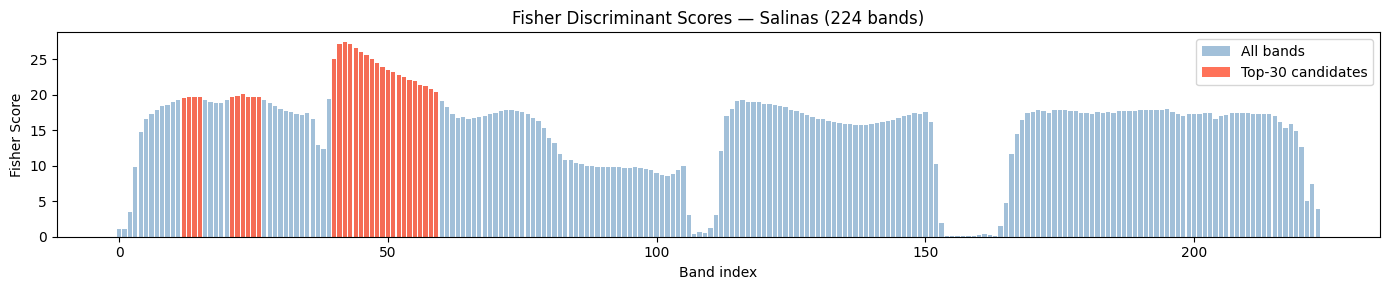


QUBO matrix : 30x30
Ising h     : [22.303, 23.290]
Non-zero J  : 217 terms
QUBO formulation complete ✓


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — Fisher Scores & QUBO Formulation
# ═══════════════════════════════════════════════════════════════════════════
n_fisher = min(FISHER_SAMPLES, len(y_labeled))
X_fisher, _, y_fisher, _ = train_test_split(
    X_labeled, y_labeled,
    train_size=n_fisher, stratify=y_labeled, random_state=42
)
print(f'Fisher subsample: {n_fisher} pixels from {len(y_labeled):,} total')

def compute_fisher_scores(X, y):
    classes = np.unique(y)
    mu      = X.mean(axis=0)
    between = np.zeros(X.shape[1])
    within  = np.zeros(X.shape[1])
    for c in classes:
        Xc = X[y == c]
        nc = len(Xc)
        mc = Xc.mean(axis=0)
        between += nc * (mc - mu) ** 2
        within  += nc * Xc.var(axis=0)
    return between / (within + 1e-12)

print(f'Computing Fisher scores for all {N_ALL_BANDS} bands...')
scaler_fisher   = StandardScaler()
X_fisher_scaled = scaler_fisher.fit_transform(X_fisher)
fisher_scores   = compute_fisher_scores(X_fisher_scaled, y_fisher)

candidate_idx        = np.argsort(fisher_scores)[::-1][:N_CANDIDATE_BANDS]
candidate_idx_sorted = np.sort(candidate_idx)

print(f'\nTop {N_CANDIDATE_BANDS} candidate bands (1-indexed):')
print('  ' + '  '.join([f'B{b+1}' for b in candidate_idx_sorted]))

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(N_ALL_BANDS), fisher_scores, color='steelblue', alpha=0.5, label='All bands')
ax.bar(candidate_idx, fisher_scores[candidate_idx], color='tomato', alpha=0.9,
       label=f'Top-{N_CANDIDATE_BANDS} candidates')
ax.set_xlabel('Band index'); ax.set_ylabel('Fisher Score')
ax.set_title(f'Fisher Discriminant Scores — Salinas ({N_ALL_BANDS} bands)')
ax.legend(); plt.tight_layout(); plt.show()

cand_data   = X_fisher_scaled[:, candidate_idx]
corr_matrix = np.corrcoef(cand_data.T)
cand_scores = fisher_scores[candidate_idx]

def build_qubo(scores, corr, k, A=QUBO_PENALTY, B=CORR_PENALTY):
    n = len(scores)
    s = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -s[i] + A * (1 - 2 * k)
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] = B * abs(corr[i, j]) + 2 * A
    return Q

def qubo_to_ising(Q):
    n = Q.shape[0]
    h = np.zeros(n); J = np.zeros((n, n)); offset = 0.0
    for i in range(n):
        h[i]   += -Q[i, i] / 2
        offset +=  Q[i, i] / 2
    for i in range(n):
        for j in range(i + 1, n):
            J[i, j] +=  Q[i, j] / 4
            h[i]    += -Q[i, j] / 4
            h[j]    += -Q[i, j] / 4
            offset  +=  Q[i, j] / 4
    return h, J, offset

Q_matrix = build_qubo(cand_scores, corr_matrix, N_BANDS_SELECT)
h_ising, J_ising, ising_offset = qubo_to_ising(Q_matrix)
n_qaoa_qubits = Q_matrix.shape[0]

print(f'\nQUBO matrix : {n_qaoa_qubits}x{n_qaoa_qubits}')
print(f'Ising h     : [{h_ising.min():.3f}, {h_ising.max():.3f}]')
print(f'Non-zero J  : {int((np.abs(J_ising)>0.01).sum()//2)} terms')
print('QUBO formulation complete ✓')

qiskit_runtime_service._discover_account:WARNING:2026-03-24 02:09:12,030: Loading account with the given token. A saved account will not be used.


QAOA circuit: 30 qubits, depth=175

Connecting to IBM Quantum...
  Connected to : ibm_fez
  Queue        : 0 jobs waiting

Transpiling...
  Transpiled depth : 1241

Submitting 16 circuits...
  Job ID  : d70v4l0v5rlc73f6hlb0
  Backend : ibm_fez  ← REAL IBM QUANTUM HARDWARE

Waiting for results...
  [QUEUED]   [DONE] 
  Done in 0.3 minutes

QUANTUM QUBO BAND SELECTION RESULT
  Backend   : ibm_fez  (REAL IBM QUANTUM HARDWARE)
  Job ID    : d70v4l0v5rlc73f6hlb0
  QUBO cost : -1946.5006
  Selected 20 bands (1-indexed): [np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57)]
    Band  13  Fisher = 19.6125
    Band  14  Fisher = 19.6884
    Band  15  Fisher = 19.7404
    Band  16  Fisher = 19.6443
    Band  22  Fisher = 19.6386
    Band  23  Fisher = 19.8760
    Band  24 

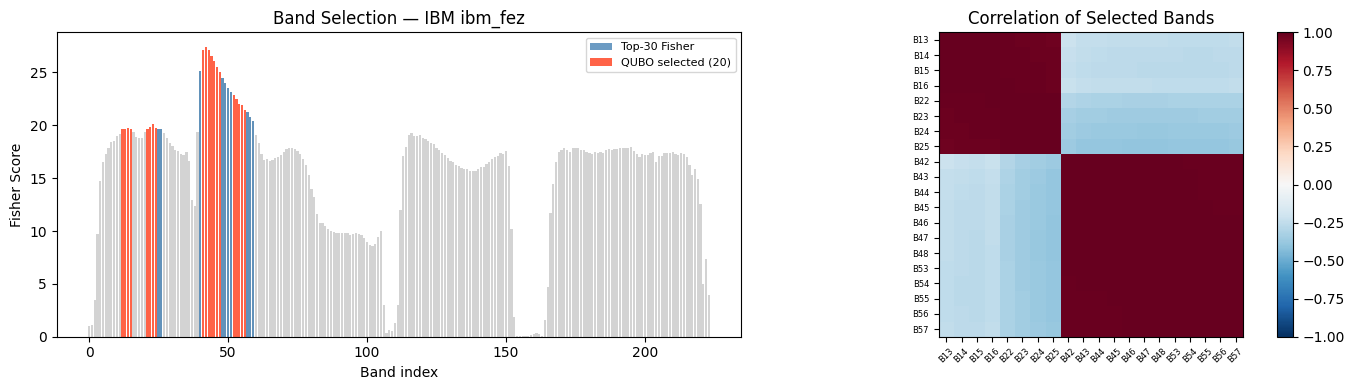

In [5]:
import os
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — QUBO Band Selection via IBM Quantum Real Hardware
# ═══════════════════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'qiskit>=2.0.0', 'qiskit-ibm-runtime>=0.30.0'])

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

IBM_API_TOKEN = os.environ.get('IBM_QUANTUM_TOKEN', '')  # set via environment variable, do NOT hardcode
IBM_INSTANCE  = os.environ.get('IBM_QUANTUM_INSTANCE', '')  # set via environment variable, do NOT hardcode

QAOA_SHOTS = 1024
N_GAMMA    = 4
N_BETA     = 4

def build_qaoa_circuit(h, J, p=1, j_threshold=0.01):
    n     = len(h)
    gamma = ParameterVector('g', p)
    beta  = ParameterVector('b', p)
    qc    = QuantumCircuit(n)
    qc.h(range(n))
    for layer in range(p):
        for i in range(n):
            for j in range(i + 1, n):
                if abs(J[i, j]) > j_threshold:
                    qc.cx(i, j)
                    qc.rz(2 * gamma[layer] * J[i, j], j)
                    qc.cx(i, j)
        for i in range(n):
            if abs(h[i]) > j_threshold:
                qc.rz(2 * gamma[layer] * h[i], i)
        for i in range(n):
            qc.rx(2 * beta[layer], i)
    qc.measure_all()
    return qc, gamma, beta

qaoa_qc, gamma_pv, beta_pv = build_qaoa_circuit(h_ising, J_ising, p=QAOA_DEPTH)
print(f'QAOA circuit: {qaoa_qc.num_qubits} qubits, depth={qaoa_qc.depth()}')

print('\nConnecting to IBM Quantum...')
service = QiskitRuntimeService(
    channel  = 'ibm_quantum_platform',
    token    = IBM_API_TOKEN,
    instance = IBM_INSTANCE,
)
backend = service.least_busy(
    operational=True, simulator=False,
    min_num_qubits=n_qaoa_qubits
)
print(f'  Connected to : {backend.name}')
print(f'  Queue        : {backend.status().pending_jobs} jobs waiting')

print('\nTranspiling...')
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
transpiled_qc = pm.run(qaoa_qc)
print(f'  Transpiled depth : {transpiled_qc.depth()}')

gamma_grid  = np.linspace(0.05, np.pi,     N_GAMMA)
beta_grid   = np.linspace(0.05, np.pi / 2, N_BETA)
param_pairs = list(itertools.product(gamma_grid, beta_grid))

sampler = Sampler(mode=backend)
sampler.options.default_shots = QAOA_SHOTS

bound_circuits = []
for g_val, b_val in param_pairs:
    pmap = {gamma_pv[0]: g_val, beta_pv[0]: b_val}
    bound_circuits.append(transpiled_qc.assign_parameters(pmap))

print(f'\nSubmitting {len(bound_circuits)} circuits...')
job    = sampler.run(bound_circuits)
job_id = job.job_id()
print(f'  Job ID  : {job_id}')
print(f'  Backend : {backend.name}  ← REAL IBM QUANTUM HARDWARE')
print('\nWaiting for results...')

t0 = time.time()
while True:
    try:
        status_str = str(job.status()).upper()
        print(f'  [{status_str}]', end=' ', flush=True)
        if any(s in status_str for s in ['DONE', 'COMPLETED']):
            break
        if any(s in status_str for s in ['ERROR', 'CANCELLED', 'FAILED']):
            raise RuntimeError(f'Job failed: {status_str}')
    except RuntimeError:
        raise
    except Exception:
        pass
    time.sleep(15)
print(f'\n  Done in {(time.time()-t0)/60:.1f} minutes')

result     = job.result()
all_counts = []
for k in range(len(bound_circuits)):
    counts = result[k].data.meas.get_counts()
    all_counts.append(counts)

def qubo_cost(bits, Q):
    x = np.array(bits, dtype=float)
    return float(x @ Q @ x)

best_cost      = float('inf')
best_gamma_val = None
best_beta_val  = None
best_local_idx = None

for cnt_dict, (g_val, b_val) in zip(all_counts, param_pairs):
    for bs in cnt_dict:
        bits = [int(c) for c in reversed(bs)]
        if sum(bits) == N_BANDS_SELECT:
            cost = qubo_cost(bits, Q_matrix)
            if cost < best_cost:
                best_cost      = cost
                best_gamma_val = g_val
                best_beta_val  = b_val
                best_local_idx = [i for i, b in enumerate(bits) if b == 1]

if best_local_idx is None:
    print('No exact-k solution — using closest approximate')
    best_approx = None
    for cnt_dict in all_counts:
        for bs in cnt_dict:
            bits = [int(c) for c in reversed(bs)]
            if best_approx is None or \
               abs(sum(bits)-N_BANDS_SELECT) < abs(sum(best_approx)-N_BANDS_SELECT):
                best_approx = bits
    best_local_idx = [i for i, b in enumerate(best_approx) if b == 1][:N_BANDS_SELECT]

selected_band_idx = np.sort(candidate_idx[best_local_idx])

print('\n' + '=' * 65)
print('QUANTUM QUBO BAND SELECTION RESULT')
print('=' * 65)
print(f'  Backend   : {backend.name}  (REAL IBM QUANTUM HARDWARE)')
print(f'  Job ID    : {job_id}')
print(f'  QUBO cost : {best_cost:.4f}')
print(f'  Selected {N_BANDS_SELECT} bands (1-indexed): {list(selected_band_idx + 1)}')
for b in selected_band_idx:
    print(f'    Band {b+1:3d}  Fisher = {fisher_scores[b]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.bar(range(N_ALL_BANDS), fisher_scores, color='lightgray')
ax.bar(candidate_idx, fisher_scores[candidate_idx], color='steelblue',
       alpha=0.8, label=f'Top-{N_CANDIDATE_BANDS} Fisher')
ax.bar(selected_band_idx, fisher_scores[selected_band_idx], color='tomato',
       label=f'QUBO selected ({N_BANDS_SELECT})')
ax.set_xlabel('Band index'); ax.set_ylabel('Fisher Score')
ax.set_title(f'Band Selection — IBM {backend.name}')
ax.legend(fontsize=8)
ax2 = axes[1]
corr_sel = np.corrcoef(X_fisher_scaled[:, selected_band_idx].T)
im = ax2.imshow(corr_sel, cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_title('Correlation of Selected Bands')
ax2.set_xticks(range(N_BANDS_SELECT))
ax2.set_yticks(range(N_BANDS_SELECT))
ax2.set_xticklabels([f'B{b+1}' for b in selected_band_idx], rotation=45, fontsize=6)
ax2.set_yticklabels([f'B{b+1}' for b in selected_band_idx], fontsize=6)
plt.colorbar(im, ax=ax2)
plt.tight_layout(); plt.show()

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — Prepare Full Dataset with Spectral + Spatial Features
# Features = 20 QUBO bands + 20 spatial means + 20 spatial stds = 60 total
# ═══════════════════════════════════════════════════════════════════════════
print('=' * 65)
print('PREPARING FULL DATASET WITH SPATIAL-SPECTRAL FEATURES')
print('=' * 65)

X_spectral = X_labeled[:, selected_band_idx].astype(np.float64)
print(f'  Spectral features : {X_spectral.shape[1]} (QUBO-selected bands)')

print(f'  Computing {SPATIAL_WINDOW}x{SPATIAL_WINDOW} spatial features...')
spatial_means = np.zeros((len(y_labeled), len(selected_band_idx)))
spatial_stds  = np.zeros((len(y_labeled), len(selected_band_idx)))

for fi, band_idx in enumerate(selected_band_idx):
    band_img    = img_full[:, :, band_idx].astype(np.float64)
    mean_img    = uniform_filter(band_img, size=SPATIAL_WINDOW)
    mean_sq_img = uniform_filter(band_img ** 2, size=SPATIAL_WINDOW)
    std_img     = np.sqrt(np.maximum(mean_sq_img - mean_img ** 2, 0))
    for pi, (row, col) in enumerate(labeled_positions):
        spatial_means[pi, fi] = mean_img[row, col]
        spatial_stds[pi, fi]  = std_img[row, col]

print(f'  Spatial mean features : {spatial_means.shape[1]}')
print(f'  Spatial std  features : {spatial_stds.shape[1]}')

X_combined = np.hstack([X_spectral, spatial_means, spatial_stds])
n_features  = X_combined.shape[1]
print(f'\n  Total features : {n_features} ({N_BANDS_SELECT} spectral + {N_BANDS_SELECT} spatial_mean + {N_BANDS_SELECT} spatial_std)')

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_combined)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_labeled,
    test_size=TEST_SPLIT, stratify=y_labeled, random_state=42
)

# XGBoost needs 0-indexed labels
y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1

CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

print(f'\n  Train set : {X_train.shape[0]:,} pixels  x  {n_features} features')
print(f'  Test  set : {X_test.shape[0]:,} pixels  x  {n_features} features')
print()
print(f'  Class distribution in test set:')
for c in unique_cls:
    cnt  = (y_test == c).sum()
    name = CLASS_NAMES.get(int(c), f'Class {c}')
    print(f'    {int(c):2d}  {name:35s}: {cnt:5,}')
print('=' * 65)
print('\n✓ Ready for classification. Run each classifier cell below.')

PREPARING FULL DATASET WITH SPATIAL-SPECTRAL FEATURES
  Spectral features : 20 (QUBO-selected bands)
  Computing 3x3 spatial features...
  Spatial mean features : 20
  Spatial std  features : 20

  Total features : 60 (20 spectral + 20 spatial_mean + 20 spatial_std)

  Train set : 48,716 pixels  x  60 features
  Test  set : 5,413 pixels  x  60 features

  Class distribution in test set:
     1  Broccoli_green_weeds_1             :   201
     2  Broccoli_green_weeds_2             :   373
     3  Fallow                             :   197
     4  Fallow_rough_plow                  :   139
     5  Fallow_smooth                      :   268
     6  Stubble                            :   396
     7  Celery                             :   358
     8  Grapes_untrained                   : 1,127
     9  Soil_vinyard_develop               :   620
    10  Corn_senesced_green_weeds          :   328
    11  Lettuce_romaine_4wk                :   107
    12  Lettuce_romaine_5wk                :   19

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — Random Forest
# ═══════════════════════════════════════════════════════════════════════════
print('Training Random Forest...'); t0 = time.time()
search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {'n_estimators': randint(200, 600), 'max_depth': randint(10, 30),
     'min_samples_leaf': randint(1, 6), 'max_features': ['sqrt', 'log2']},
    n_iter=20, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['Random Forest'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training Random Forest...
  ✓ Results saved to /content/results_backup.pkl  [['Random Forest']]
  CV: 93.04%  Train: 99.55%  Test: 93.29%  Gap: 6.3pp  Time: 10464s


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — Extra Trees
# ═══════════════════════════════════════════════════════════════════════════
print('Training Extra Trees...'); t0 = time.time()
search = RandomizedSearchCV(
    ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    {'n_estimators': randint(200, 600), 'max_depth': randint(10, 30),
     'min_samples_leaf': randint(1, 6), 'max_features': ['sqrt', 'log2']},
    n_iter=20, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['Extra Trees'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training Extra Trees...
  ✓ Results saved to /content/results_backup.pkl  [['Random Forest', 'Extra Trees']]
  CV: 93.20%  Train: 99.99%  Test: 93.29%  Gap: 6.7pp  Time: 1884s


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — XGBoost
# ═══════════════════════════════════════════════════════════════════════════
print('Training XGBoost...'); t0 = time.time()
search = RandomizedSearchCV(
    XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1,
                  eval_metric='mlogloss', verbosity=0),
    {'n_estimators': randint(200, 500), 'max_depth': randint(4, 10),
     'learning_rate': loguniform(0.02, 0.3),
     'subsample': [0.7, 0.8, 0.9, 1.0],
     'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
     'min_child_weight': randint(1, 10)},
    n_iter=20, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train_xgb)   # uses 0-indexed labels
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train_xgb, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test_xgb,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['XGBoost'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed,
    'use_xgb_labels': True}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training XGBoost...
  ✓ Results saved to /content/results_backup.pkl  [['Random Forest', 'Extra Trees', 'XGBoost']]
  CV: 94.40%  Train: 100.00%  Test: 94.85%  Gap: 5.2pp  Time: 6953s


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — HistGradientBoosting
# ═══════════════════════════════════════════════════════════════════════════
print('Training HistGradientBoosting...'); t0 = time.time()
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
    {'max_iter': randint(150, 400), 'max_depth': randint(4, 10),
     'learning_rate': loguniform(0.02, 0.3),
     'l2_regularization': loguniform(1e-4, 1.0),
     'min_samples_leaf': randint(5, 30)},
    n_iter=20, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['HistGradientBoosting'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training HistGradientBoosting...
  ✓ Results saved to /content/results_backup.pkl  [['Random Forest', 'Extra Trees', 'XGBoost', 'HistGradientBoosting']]
  CV: 93.61%  Train: 97.76%  Test: 93.40%  Gap: 4.4pp  Time: 3341s


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11 — KNN
# ═══════════════════════════════════════════════════════════════════════════
print('Training KNN...'); t0 = time.time()
search = RandomizedSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    {'n_neighbors': randint(3, 20), 'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan']},
    n_iter=15, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['KNN'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training KNN...
  ✓ Results saved to /content/results_backup.pkl  [['Random Forest', 'Extra Trees', 'XGBoost', 'HistGradientBoosting', 'KNN']]
  CV: 91.35%  Train: 100.00%  Test: 91.82%  Gap: 8.2pp  Time: 1293s


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 12 — Logistic Regression
# ═══════════════════════════════════════════════════════════════════════════
print('Training Logistic Regression...'); t0 = time.time()
search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    {'C': loguniform(0.1, 100), 'solver': ['lbfgs', 'saga']},
    n_iter=15, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['Logistic Regression'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training Logistic Regression...
  ✓ Results saved to /content/results_backup.pkl  [['Random Forest', 'Extra Trees', 'XGBoost', 'HistGradientBoosting', 'KNN', 'Logistic Regression']]
  CV: 89.91%  Train: 90.25%  Test: 90.28%  Gap: -0.0pp  Time: 15419s


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 13 — MLP Neural Net
# ═══════════════════════════════════════════════════════════════════════════
print('Training MLP Neural Net...'); t0 = time.time()
search = RandomizedSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True,
                  validation_fraction=0.1, n_iter_no_change=15, random_state=42),
    {'hidden_layer_sizes': [(256, 128), (512, 256, 128), (128, 64)],
     'alpha': loguniform(1e-5, 1e-2),
     'learning_rate_init': loguniform(1e-4, 1e-2)},
    n_iter=15, cv=CV, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=0
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['MLP Neural Net'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed:.0f}s')

Training MLP Neural Net...


NameError: name 'time' is not defined

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 14 — SVM (takes 1-2 hours — run separately)
# ═══════════════════════════════════════════════════════════════════════════
print('Training SVM (RBF) — this takes 1-2 hours...')
print(f'Train: {X_train.shape[0]:,} pixels  |  Test: {X_test.shape[0]:,} pixels')
t0 = time.time()
search = RandomizedSearchCV(
    SVC(class_weight='balanced', random_state=42,
        cache_size=4000, probability=False),
    {'C': loguniform(10, 1000), 'gamma': loguniform(1e-4, 1.0), 'kernel': ['rbf']},
    n_iter=10, cv=5, scoring='accuracy', refit=True,
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train, y_train)
clf       = search.best_estimator_
cv_score  = search.best_score_ * 100
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc  = accuracy_score(y_test,  clf.predict(X_test))  * 100
elapsed   = time.time() - t0
results['SVM (RBF)'] = {'clf': clf, 'cv_score': cv_score,
    'train_acc': train_acc, 'test_acc': test_acc, 'train_time': elapsed}
save_results(results)
print(f'  CV: {cv_score:.2f}%  Train: {train_acc:.2f}%  Test: {test_acc:.2f}%  Gap: {train_acc-test_acc:.1f}pp  Time: {elapsed/60:.1f}min')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 15 — Summary Table (run after all classifiers are done)
# ═══════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 80)
print(f'FINAL RESULTS — ALL CLASSIFIERS — {n_features} FEATURES')
print(f'Train: {X_train.shape[0]:,} pixels  |  Test: {X_test.shape[0]:,} pixels  |  {CV_FOLDS}-fold CV')
print('=' * 80)
print(f'{"Rank  Classifier":<28}  {"CV":>8}  {"Train":>8}  {"Test":>8}  {"Gap":>7}  {"Time":>8}')
print('-' * 80)
for rank, n in enumerate(
    sorted(results.keys(), key=lambda n: results[n]['test_acc'], reverse=True), 1
):
    r   = results[n]
    gap = r['train_acc'] - r['test_acc']
    mrk = '  ◀ BEST' if rank == 1 else ''
    print(f'{rank:>2}.  {n:<24}  {r["cv_score"]:>7.2f}%  '
          f'{r["train_acc"]:>7.2f}%  {r["test_acc"]:>7.2f}%  '
          f'{gap:>6.1f}pp  {r["train_time"]:>6.1f}s{mrk}')
print('=' * 80)
best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f'\n✅  Best: {best_name}  →  Test accuracy: {results[best_name]["test_acc"]:.2f}%')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 16 — Per-Class Report for Best Classifier
# ═══════════════════════════════════════════════════════════════════════════
best_name = max(results, key=lambda n: results[n]['test_acc'])
best_clf  = results[best_name]['clf']

# Handle XGBoost label difference
if results[best_name].get('use_xgb_labels'):
    y_pred_raw = best_clf.predict(X_test)
    y_pred     = y_pred_raw + 1
else:
    y_pred = best_clf.predict(X_test)

print(f'Per-Class Accuracy — {best_name}')
print('=' * 70)
per_class_acc = []
for c in unique_cls:
    mask = y_test == c
    if mask.sum() == 0:
        continue
    acc  = accuracy_score(y_test[mask], y_pred[mask]) * 100
    per_class_acc.append(acc)
    bar  = '█' * int(acc / 5)
    name = CLASS_NAMES.get(int(c), f'Class {c}')
    print(f'  {int(c):2d}  {name:35s}: {acc:6.2f}%  {bar}')

oa    = accuracy_score(y_test, y_pred) * 100
aa    = np.mean(per_class_acc)
kappa = cohen_kappa_score(y_test, y_pred)

print(f'\n  Overall Accuracy (OA) : {oa:.2f}%')
print(f'  Average Accuracy (AA) : {aa:.2f}%')
print(f'  Kappa Coefficient     : {kappa:.4f}')
print('=' * 70)
print()
print(classification_report(
    y_test, y_pred,
    target_names=[CLASS_NAMES.get(int(c), f'C{c}') for c in unique_cls],
    zero_division=0
))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 17 — Results Summary Charts
# ═══════════════════════════════════════════════════════════════════════════
names      = list(results.keys())
train_accs = [results[n]['train_acc'] for n in names]
test_accs  = [results[n]['test_acc']  for n in names]
cv_scores  = [results[n]['cv_score']  for n in names]
gaps       = [t - v for t, v in zip(train_accs, test_accs)]

x = np.arange(len(names))
w = 0.26

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ax = axes[0]
ax.bar(x - w, train_accs, w, label='Train',       color='#64B5F6', alpha=0.9)
ax.bar(x,     cv_scores,  w, label='CV (5-fold)', color='#FFB74D', alpha=0.9)
ax.bar(x + w, test_accs,  w, label='Test',        color='#EF5350', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(70, 105)
ax.set_title(
    f'Accuracy — {N_BANDS_SELECT} Quantum Bands + Spatial Features\n'
    f'Full dataset: {len(y_labeled):,} pixels  |  {n_features} total features', fontsize=10
)
ax.legend(fontsize=9)
ax.axhline(y=max(test_accs), color='green', linestyle='--', alpha=0.5)
for i, v in enumerate(test_accs):
    ax.text(x[i] + w, v + 0.3, f'{v:.1f}', ha='center', va='bottom', fontsize=7, color='darkred')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bar_cols = ['#FF7043' if g > 10 else '#66BB6A' for g in gaps]
ax2.bar(x, gaps, color=bar_cols, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Train − Test gap (pp)')
ax2.set_title('Overfitting Gap per Classifier', fontsize=10)
ax2.axhline(y=0,  color='black', linewidth=0.8)
ax2.axhline(y=10, color='orange', linestyle='--', alpha=0.7)
ax2.grid(axis='y', alpha=0.3)
for bar, g in zip(ax2.patches, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, max(bar.get_height(), 0) + 0.1,
             f'{g:.1f}', ha='center', va='bottom', fontsize=8)
plt.suptitle(
    f'Salinas — IBM Quantum QUBO ({N_BANDS_SELECT} bands) + Spatial Features\n'
    f'Full dataset {len(y_labeled):,} pixels  |  {CV_FOLDS}-fold CV',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 18 — Confusion Matrix (Best Classifier)
# ═══════════════════════════════════════════════════════════════════════════
cm      = confusion_matrix(y_test, y_pred, labels=unique_cls)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='Recall (%)')

tick_labels = [CLASS_NAMES.get(int(c), f'C{c}') for c in unique_cls]
ax.set_xticks(range(len(unique_cls)))
ax.set_yticks(range(len(unique_cls)))
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(tick_labels, fontsize=7)

for i in range(len(unique_cls)):
    for j in range(len(unique_cls)):
        v = cm_norm[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=6, color='white' if v > 60 else 'black')

ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title(
    f'Confusion Matrix — {best_name}\n'
    f'{N_BANDS_SELECT} Quantum Bands + Spatial Features  |  '
    f'Test accuracy: {results[best_name]["test_acc"]:.2f}%',
    fontsize=11
)
plt.tight_layout()
plt.show()

NameError: name 'confusion_matrix' is not defined